# Perceptron Classifier: From Synthetic Tests to Energy Trends
**Developer:** Alexandra Yu  
**Course:** CMOR 438  

---

## 1. Introduction
The **Perceptron** is a fundamental building block of neural networks. It is a **binary linear classifier**, meaning it learns a weight vector that separates two classes using a straight line (in 2D space).

### Notebook Objectives:
1. **Part 1: Synthetic Validation**: We first test the implementation on "Toy Data"—two perfectly separable clusters—to ensure the mathematical logic of our `fit` and `predict` methods is sound.
2. **Part 2: Real-World Analysis**: We then apply the model to the `energy.csv` dataset to see if we can classify countries as **High** or **Low** renewable energy adopters based on their consumption patterns.

---

In [1]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Tell Python to look in the 'src' folder for our custom package
sys.path.append(os.path.abspath("../../../src"))

from my_ml_package.supervised.perceptron import Perceptron

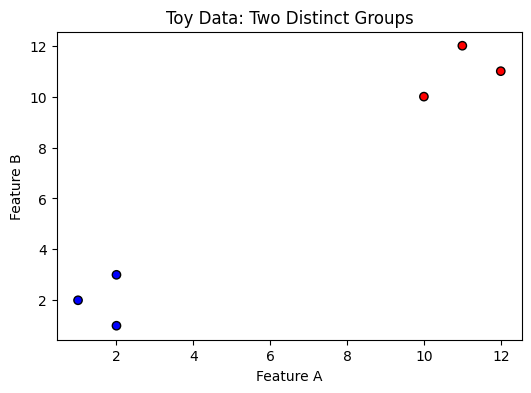

Sanity Check: Toy model trained and visualized.


In [2]:
# 1. Create synthetic data (Cluster 1: low values, Cluster 2: high values)
X_toy = np.array([[1, 2], [2, 1], [2, 3], [10, 10], [11, 12], [12, 11]])
y_toy = np.array([0, 0, 0, 1, 1, 1]) 

# 2. Train the model on the toy data
toy_model = Perceptron(learning_rate=0.1, epochs=10)
toy_model.fit(X_toy, y_toy)

# 3. Visualize the toy data
plt.figure(figsize=(6, 4))
plt.scatter(X_toy[:,0], X_toy[:,1], c=y_toy, cmap='bwr', edgecolors='k')
plt.title("Toy Data: Two Distinct Groups")
plt.xlabel("Feature A")
plt.ylabel("Feature B")
plt.show()

print("Sanity Check: Toy model trained and visualized.")

## 2. Data Loading
We are using the `energy.csv` dataset, which contains global energy consumption and renewable share data.

In [3]:
# Load the dataset
df_energy = pd.read_csv('../../../data/energy.csv')

print(f"Dataset loaded successfully with {df_energy.shape[0]} rows.")
df_energy.head()

Dataset loaded successfully with 10000 rows.


,Country,Year,Total Energy Consumption (TWh),Per Capita Energy Use (kWh),Renewable Energy Share (%),Fossil Fuel Dependency (%),Industrial Energy Use (%),Household Energy Use (%),Carbon Emissions (Million Tons),Energy Price Index (USD/kWh)
0,Canada,2018,9525.38,42301.43,13.70,70.47,45.18,19.96,3766.11,0.12
1,Germany,2020,7922.08,36601.38,33.63,41.95,34.32,22.27,2713.12,0.08
2,Russia,2002,6630.01,41670.20,10.82,39.32,53.66,26.44,885.98,0.26
3,Brazil,2010,8580.19,10969.58,73.24,16.71,30.55,27.60,1144.11,0.47
4,Canada,2006,848.88,32190.85,73.60,74.86,42.39,23.43,842.39,0.48


## 3. Data Preprocessing
To prepare the data for the Perceptron, we perform the following steps:
1. **Filter:** Isolate the most recent year for a current snapshot.
2. **Labeling:** Create a binary target based on the global median of `renewable_share`.
3. **Feature Selection:** Define $X$ using fossil fuel and total consumption.
4. **Standardization:** Scale features to have a mean of 0 and a standard deviation of 1. This prevents features with larger scales from dominating the weight updates.

In [4]:
# 1. Filter for the latest year (Changed 'year' to 'Year')
latest_year = df_energy[df_energy['Year'] == df_energy['Year'].max()].copy()

# 2. Create binary label (Changed 'renewable_share' to 'Renewable Energy Share (%)')
median_share = latest_year['Renewable Energy Share (%)'].median()
latest_year['target'] = (latest_year['Renewable Energy Share (%)'] > median_share).astype(int)

# 3. Select features (X) and target (y)
# Changed to match: 'Fossil Fuel Dependency (%)' and 'Total Energy Consumption (TWh)'
X = latest_year[['Fossil Fuel Dependency (%)', 'Total Energy Consumption (TWh)']].values
y = latest_year['target'].values

# 4. Standardize the data
X = (X - X.mean(axis=0)) / X.std(axis=0)

print(f"Preprocessing complete.")
print(f"Global Median Renewable Share for {df_energy['Year'].max()}: {median_share:.2f}%")

Preprocessing complete.
Global Median Renewable Share for 2024: 49.23%


## 4. Model Training
We initialize the Perceptron with a learning rate ($\eta$) of 0.01. We run the training for 500 epochs to ensure the weight vector $w$ and bias $b$ converge.

In [5]:
# Initialize and train
model = Perceptron(learning_rate=0.01, epochs=500)
model.fit(X, y)

print("Model training complete.")
print(f"Final Weights: {model.weights}")
print(f"Final Bias: {model.bias}")

Model training complete.
Final Weights: [-0.01006162 -0.00913459]
Final Bias: -0.010000000000000004


## 5. Visualizing the Decision Boundary
Below, we plot the data points against the decision boundary learned by the model. The colored regions represent the areas where the Perceptron would predict "High" (Green) or "Low" (Red) renewable adoption.

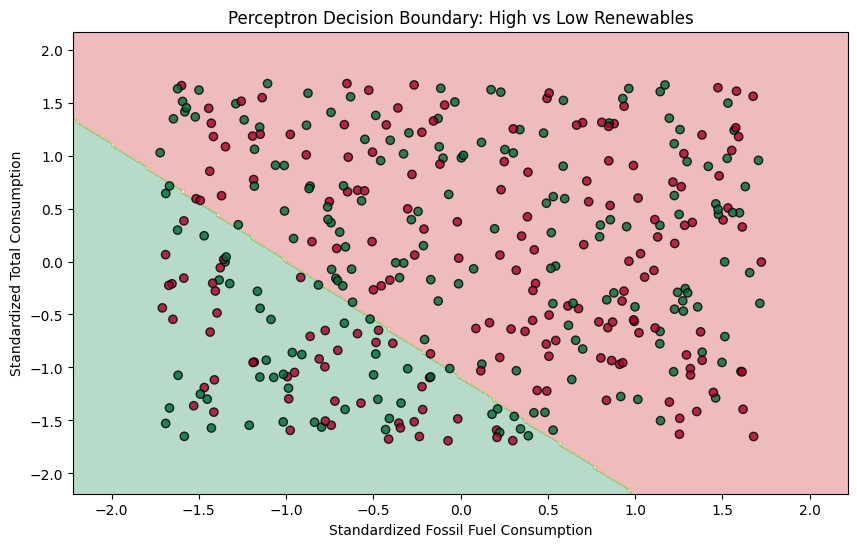

In [6]:
plt.figure(figsize=(10, 6))

# Create a mesh grid
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# Predict over the grid
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot results
plt.contourf(xx, yy, Z, alpha=0.3, cmap='RdYlGn')
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='RdYlGn', edgecolors='k', alpha=0.8)

plt.xlabel('Standardized Fossil Fuel Consumption')
plt.ylabel('Standardized Total Consumption')
plt.title('Perceptron Decision Boundary: High vs Low Renewables')
plt.show()

## 6. Conclusion
Based on the plot above, we can determine if the energy profiles are **linearly separable**. If the boundary successfully splits the two colors, the Perceptron has converged on a valid solution for this classification task.